# Public Speaking dimension — end-to-end demo (Module 9)

**Runs on Google Colab GPU only** (Runtime → Change runtime type → **T4 GPU**).
Drive it from VS Code via the Google Colab extension, then **Run all**.

| Real (this notebook computes it) | Stubbed (owned by another module) |
|---|---|
| eye_contact, posture (YOLOv8-pose) | slide_structure → Module 4 |
| speech_pace, voice_stability (Librosa) | audience_engagement → Module 8 |
| opening_closing_impact (Qwen2.5-3B LLM) | |

No API keys — all intelligence is local/open-weight.


In [1]:
# ── ENVIRONMENT DETECTION + GPU CHECK ──────────────────────────────────────
import subprocess, sys, os

IS_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IS_COLAB:
    result = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total,memory.free",
                             "--format=csv,noheader"], capture_output=True, text=True)
    if result.returncode != 0:
        print("\u274c  NO GPU detected.")
        print("    Fix: Runtime \u2192 Change runtime type \u2192 T4 GPU \u2192 Save \u2192 Reconnect")
        raise SystemExit("No GPU \u2014 stopping to prevent slow CPU run.")
    print("\u2705  GPU detected:")
    for line in result.stdout.strip().split("\n"):
        name, total, free = [x.strip() for x in line.split(",")]
        print(f"    {name}  |  Total: {total}  |  Free: {free}")
    import importlib
    if importlib.util.find_spec("torch"):
        import torch
        if torch.cuda.is_available():
            print(f"    torch CUDA: {torch.cuda.get_device_name(0)}")
        else:
            print("    \u26a0\ufe0f  torch installed but CUDA not available")
    else:
        print("    (torch not yet installed \u2014 will be installed in Step 1)")
else:
    print("\U0001f5a5\ufe0f  Local Mac \u2014 GPU cells skipped; synthetic data used for Steps 1-4.")
    print("    Steps 5-10 (pure Python) run end-to-end.")


✅  GPU detected:
    Tesla T4  |  Total: 15360 MiB  |  Free: 14913 MiB
    torch CUDA: Tesla T4


In [2]:
# ── PROJECT SETUP (auto-update + auto-reload, no restart needed) ─────────────
# Colab pulls the latest code from GitHub AND purges any stale cached modules,
# so a `git push` from your Mac + Run All is all it takes — no runtime restart.
#
# ONE-TIME Colab setup for the PRIVATE repo:
#   1. GitHub → Settings → Developer settings → Fine-grained tokens →
#      read-only token for `personalised-lms-service` (Contents: Read).
#   2. Colab → 🔑 key icon → add secret GITHUB_TOKEN, enable "Notebook access".
#   (Public repo? The token step is unnecessary.)

import os, sys, subprocess

IS_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')
REPO = "github.com/hanvith6/personalised-lms-service"

if IS_COLAB:
    PROJECT_PATH = '/content/personalised-lms-service'

    if os.path.exists(os.path.join(PROJECT_PATH, '.git')):
        subprocess.run(["git", "-C", PROJECT_PATH, "pull", "--quiet"], check=False)
        print("\u2705  git pull \u2014 repo updated to latest")
    else:
        url = f"https://{REPO}"
        try:
            from google.colab import userdata
            _tok = userdata.get("GITHUB_TOKEN")
            if _tok:
                url = f"https://{_tok}@{REPO}"
        except Exception:
            pass
        subprocess.run(["git", "clone", "--quiet", url, PROJECT_PATH], check=True)
        print("\u2705  git clone \u2014 repo fetched")
else:
    PROJECT_PATH = '/Users/hanvith/dev/Quant/personalised-lms-service'

if not os.path.exists(os.path.join(PROJECT_PATH, 'utils', 'taxonomy.py')):
    raise FileNotFoundError(
        f"Project not found at {PROJECT_PATH}\n"
        "Colab: check the GITHUB_TOKEN secret (\U0001f511 icon) and repo name.\n"
        "Local: verify PROJECT_PATH."
    )

sys.path.insert(0, PROJECT_PATH)
os.chdir(PROJECT_PATH)

# ── AUTO-RELOAD: drop stale cached modules so later cells import fresh code ───
# Without this, a warm kernel keeps the OLD module after a pull (the classic
# "I pulled but it still runs old code" trap). Purging forces re-import on next
# `from services... import ...`, so Run All picks up new code WITHOUT a restart.
_PKGS = {"utils", "services", "dimensions", "api"}
for _name in [m for m in sys.modules if m.split(".")[0] in _PKGS]:
    del sys.modules[_name]
print("\u267b\ufe0f  cleared cached project modules \u2014 fresh code will load")

print(f"\u2705  Loaded: {PROJECT_PATH}")
print(f"    IS_COLAB={IS_COLAB}  |  Files: {os.listdir(PROJECT_PATH)}")


✅  git pull — repo updated to latest
♻️  cleared cached project modules — fresh code will load
✅  Loaded: /content/personalised-lms-service
    IS_COLAB=True  |  Files: ['conftest.py', '.git', 'tests', 'push.sh', 'requirements.txt', 'run-demo.sh', 'services', 'README.md', 'frontend', 'student_presentation.mp4', 'dimensions', '.gitignore', 'requirements-api.txt', 'utils', 'HANDOFF.md', 'frames', 'api', 'yolov8n-pose.pt']


In [ ]:
# ── RUN MODE ─────────────────────────────────────────────────────────────────
# LOCAL_DEBUG = True   → synthetic data, no heavy installs, runs in ~5s anywhere
# LOCAL_DEBUG = False  → full pipeline (real video + YOLO + Whisper + Qwen2.5-3B)
#
# On local Mac : always True (IS_COLAB=False forces synthetic)
# On Colab     : set False for real scores, True for fast debug

LOCAL_DEBUG = not IS_COLAB   # auto: Mac=True, Colab=False
# LOCAL_DEBUG = True         # \u2190 uncomment to force debug mode on Colab too

# ── STUDENT VIDEO ────────────────────────────────────────────────────────────
# YouTube URL (downloaded via yt-dlp) OR a direct .mp4/.webm URL.
# Leave "" to use the built-in sample clip / synthetic fallback.
# All defaults below are TEDx / TED-Ed / OER \u2014 CC-licensed, single presenter.

STUDENT_VIDEO_URL = "https://www.youtube.com/watch?v=rW2r5uStgG0"  # Luke Bakic \u2014 Power of Reading (3:10) \u2014 clean baseline

# Alternatives (swap the line above):
#   "https://www.youtube.com/watch?v=wbftlDzIALA"  # Georgia Haukom \u2014 Effects of Lying (3:11) \u2014 clear open/close
#   "https://www.youtube.com/watch?v=OMbNoo4mCcI"  # Cameron Allen \u2014 Education For All (3:21) \u2014 strong eye contact
#   "https://www.youtube.com/watch?v=Z0LhdQIhmzk"  # Gifted Labeling (5:22) \u2014 longer, persuasive
#   "https://www.youtube.com/watch?v=V8eLdbKXGzk"  # Good vs Bad Presentation (5:13) \u2014 A/B calibration stress test

print(f"RUN MODE: {'LOCAL_DEBUG (synthetic data)' if LOCAL_DEBUG else 'FULL PIPELINE (real video + models)'}")
if STUDENT_VIDEO_URL and not LOCAL_DEBUG:
    print(f"STUDENT_VIDEO_URL: {STUDENT_VIDEO_URL}")


# \u2500\u2500 A/B WINDOW (same-speaker oracle) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
# Score only PART of the clip. For the "Good vs Bad" same-speaker test, do TWO
# Run-All passes on the SAME URL (V8eLdbKXGzk): once on the bad segment, once on
# the good segment. Each window is recorded under its own label; Step 14 then
# asserts good > bad. None = whole video.
VIDEO_START = None   # seconds, e.g. 0
VIDEO_END   = None   # seconds, e.g. 90
if not LOCAL_DEBUG and (VIDEO_START is not None or VIDEO_END is not None):
    print(f"A/B WINDOW: [{VIDEO_START}, {VIDEO_END}] seconds")

In [ ]:
# \u2500\u2500 TEST VIDEO CATALOG \u2014 paste a URL into STUDENT_VIDEO_URL above \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
# 15 vetted, yt-dlp-downloadable, CC/OER clips with stable framing.
TEST_VIDEOS = {
    # 1. MULTI-PERSON IN FRAME (2-6 people) \u2014 for option-C tracking
    "multi_person": [
        ("https://www.youtube.com/watch?v=ZNTBAKAT_WQ", "MIT OCW Local vs Expert (5:58, 2-4 ppl)"),
        ("https://www.youtube.com/watch?v=Ll8zzImnYOE", "Religious Right Panel (3:03, 4-5 ppl)"),
        ("https://www.youtube.com/watch?v=dlC_f2jfDqI", "Health Literacy Panel (9:31, 3-5 ppl)"),
        ("https://www.youtube.com/watch?v=depjUykp_wo", "STEAM Expo Panel (1:39, 2-3 ppl)"),
        ("https://www.youtube.com/watch?v=_rmYgmJN1-M", "Prop 62 News Desk (0:55, 2 ppl)"),
    ],
    # 2. SAME-SPEAKER GOOD-vs-BAD \u2014 for the A/B oracle (Step 14)
    "ab_pairs": [
        ("https://www.youtube.com/watch?v=V8eLdbKXGzk", "Project IDEA Good vs Bad (5:13) \u2605 within-clip A/B"),
        ("https://www.youtube.com/watch?v=S5c1susCPAE", "Husain Good/Bad cuts (2:29)"),
        ("https://www.youtube.com/watch?v=8ghfgC_K0Fo", "Managing Nervousness (2:10)"),
        ("https://www.youtube.com/watch?v=tEF2vNP3S9A", "Do's and Don'ts Slides (4:01)"),
        ("https://www.youtube.com/watch?v=WXe2KE5C9ag", "Bad PPT exaggerated (1:31)"),
    ],
    # 3. VARIED SINGLE-SPEAKER baselines \u2014 cadence/energy edge cases
    "baselines": [
        ("https://www.youtube.com/watch?v=Z0LhdQIhmzk", "Gifted Labeling (5:22) fast+expressive"),
        ("https://www.youtube.com/watch?v=wbftlDzIALA", "Effects of Lying (3:11) slow+rigid"),
        ("https://www.youtube.com/watch?v=rW2r5uStgG0", "Power of Reading (3:10) structured"),
        ("https://www.youtube.com/watch?v=OMbNoo4mCcI", "Education For All (3:21) younger presenter"),
        ("https://www.youtube.com/watch?v=r01KsFLKdO4", "MIT OCW Cost-Benefit (5:35) natural cadence"),
    ],
}
print("Catalog:", {k: len(v) for k, v in TEST_VIDEOS.items()})

## Step 1 — Install deps + load the local LLM

In [4]:
# ── STEP 1a: Install heavy deps (Colab full-pipeline only) ───────────────────
# Unpinned: let pip resolve against Colab's pre-installed torch / numpy / cuda.
# (Strict == pins fight Colab's base image and fail to resolve.)
# torch, numpy, requests, ffmpeg are already on Colab — only the extras here.
if not LOCAL_DEBUG:
    !pip install -q ultralytics openai-whisper librosa transformers accelerate soundfile mediapipe
    print("\u2705  deps installed")
else:
    print("\u23ed\ufe0f  LOCAL_DEBUG: skipping heavy installs.")


In [5]:
# Make the project package importable.
# Walks up from cwd to find utils/taxonomy.py; falls back to known local path.
import os, sys

LOCAL_PATH = '/Users/hanvith/dev/Quant/personalised-lms-service'

def find_root(start):
    d = os.path.abspath(start)
    for _ in range(8):
        if os.path.exists(os.path.join(d, "utils", "taxonomy.py")):
            return d
        d = os.path.dirname(d)
    return None

ROOT = find_root(os.getcwd()) or find_root(LOCAL_PATH) or LOCAL_PATH

if not os.path.exists(os.path.join(ROOT, "utils", "taxonomy.py")):
    raise RuntimeError(
        f"Project root not found (tried cwd and {LOCAL_PATH}).\n"
        "Run the PROJECT SETUP cell above first."
    )
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)
print("project root:", ROOT)


project root: /content/personalised-lms-service


In [6]:
# ── GPU MEMORY PRE-FLIGHT + AUTO-KILL ZOMBIE KERNELS ─────────────────────────
# Frees this kernel's cache, then kills any OTHER process holding the GPU
# (a leftover/zombie kernel — the "Process NNN has 13GB" OOM). SAFE: it never
# kills the current kernel (os.getpid()); in a Colab VM every GPU process is a
# Python kernel, so a foreign PID is always a stale one. Toggle off if unsure.
AUTO_KILL_ZOMBIES = True

if not LOCAL_DEBUG:
    import gc, os, time, signal, subprocess, torch

    gc.collect(); torch.cuda.empty_cache()
    me = os.getpid()

    apps = subprocess.run(
        ["nvidia-smi", "--query-compute-apps=pid,used_memory", "--format=csv,noheader,nounits"],
        capture_output=True, text=True).stdout.strip()

    killed = []
    for line in [l for l in apps.splitlines() if l.strip()]:
        try:
            pid_s, mem_s = [x.strip() for x in line.split(",")]
            pid = int(pid_s)
        except ValueError:
            continue
        if pid != me and AUTO_KILL_ZOMBIES:          # never kill ourselves
            try:
                os.kill(pid, signal.SIGKILL)
                killed.append(f"{pid} ({mem_s} MiB)")
            except (ProcessLookupError, PermissionError) as e:
                print(f"   could not kill {pid}: {e}")

    if killed:
        time.sleep(2)                                # let the driver reclaim
        gc.collect(); torch.cuda.empty_cache()
        print("\U0001f9f9  killed zombie GPU kernel(s):", ", ".join(killed))

    free, total = torch.cuda.mem_get_info()
    free_gb = free / 1e9
    status = "\u2705 ready" if free_gb >= 7 else \
             "\u26a0\ufe0f still low \u2014 Runtime \u2192 Manage sessions \u2192 Terminate, then reconnect"
    print(f"GPU free: {free_gb:.1f} / {total/1e9:.1f} GB  {status}")
else:
    print("\u23ed\ufe0f  LOCAL_DEBUG: no GPU pre-flight needed.")


GPU free: 15.5 / 15.6 GB  ✅ ready


In [7]:
# ── STEP 1b: Load LLM ────────────────────────────────────────────────────────
if not LOCAL_DEBUG:
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer

    # fp16 is the key OOM fix: torch_dtype="auto" can load Qwen-3B in fp32 (~12GB)
    # and fill the T4 before YOLO runs. fp16 \u2248 6GB, leaving room for YOLO+Whisper.
    # If you still OOM, switch MODEL_ID to "Qwen/Qwen2.5-1.5B-Instruct" (~3GB).
    MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
    tok = AutoTokenizer.from_pretrained(MODEL_ID)
    mdl = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, torch_dtype=torch.float16, device_map="auto", low_cpu_mem_usage=True)

    def llm_generate(prompt: str) -> str:
        msgs = [{"role": "user", "content": prompt}]
        text = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs = tok(text, return_tensors="pt").to(mdl.device)
        out = mdl.generate(**inputs, max_new_tokens=512, do_sample=False)
        return tok.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)

    import torch as _t
    print(f"LLM ready: {MODEL_ID} | GPU used: {_t.cuda.memory_allocated()/1e9:.1f} GB")
else:
    import urllib.request, json as _json

    _SCORE_STUB = '{"score": 7.0, "justification": "local stub \u2014 Ollama not reachable"}'
    _PATH_STUB  = _json.dumps([{
        "title": "Eye Contact Fundamentals", "dimension": "public_speaking",
        "skill_addressed": "eye_contact", "resource_type": "video",
        "difficulty": "beginner", "estimated_minutes": 20,
        "reason": "Builds camera-presence baseline.", "prerequisite_step_index": None,
    }, {
        "title": "Confident Posture Practice", "dimension": "public_speaking",
        "skill_addressed": "posture", "resource_type": "exercise",
        "difficulty": "beginner", "estimated_minutes": 15,
        "reason": "Reinforces upright stance.", "prerequisite_step_index": 0,
    }])

    def llm_generate(prompt: str) -> str:
        try:
            body = _json.dumps({"model": "mistral", "prompt": prompt, "stream": False}).encode()
            req = urllib.request.Request(
                "http://localhost:11434/api/generate", data=body,
                headers={"Content-Type": "application/json"})
            with urllib.request.urlopen(req, timeout=30) as resp:
                return _json.loads(resp.read())["response"]
        except Exception:
            return _PATH_STUB if "JSON array" in prompt else _SCORE_STUB

    print("\U0001f5a5\ufe0f  LOCAL_DEBUG: stub LLM ready (Ollama/Mistral + JSON fallback).")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:134: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

LLM ready: Qwen/Qwen2.5-3B-Instruct | GPU used: 6.2 GB


## Step 2 — Get a clip → frames → YOLOv8-pose → eye_contact + posture

Tries a license-clean download; on **any** failure falls back to a synthetic clip
(and synthetic demo pose/transcript) so the notebook always runs end-to-end.

In [8]:
import os, subprocess, hashlib, glob

USED_SYNTHETIC = LOCAL_DEBUG
VIDEO = "sample_clip.mp4"
_MAX_BYTES = 200 * 1024 * 1024   # 200 MB cap

def _sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""): h.update(chunk)
    return h.hexdigest()

if not LOCAL_DEBUG:
    # ── Path 1: YouTube / arbitrary URL via yt-dlp ───────────────────────────
    if STUDENT_VIDEO_URL and ("youtube.com" in STUDENT_VIDEO_URL or "youtu.be" in STUDENT_VIDEO_URL):
        try:
            subprocess.run(["pip", "install", "-q", "yt-dlp"], check=True)
            VIDEO = "student_presentation.mp4"
            subprocess.run(["yt-dlp", "-f", "mp4[height<=480]/best[height<=480]",
                            "-o", VIDEO, STUDENT_VIDEO_URL], check=True)
            print("\u2705  downloaded via yt-dlp:", VIDEO)
        except Exception as e:
            print("yt-dlp failed (", e, ") -> synthetic fallback")
            USED_SYNTHETIC = True

    # ── Path 2: direct .mp4/.webm URL (Wikimedia needs a User-Agent) ─────────
    else:
        import requests
        DIRECT_URL = STUDENT_VIDEO_URL or (
            "https://upload.wikimedia.org/wikipedia/commons/transcoded/9/9b/"
            "Sample_speech.ogv/Sample_speech.ogv.360p.webm")
        VIDEO = "sample_clip" + (".webm" if DIRECT_URL.endswith(".webm") else ".mp4")
        # 403-fix: Wikimedia blocks requests without a real User-Agent.
        HEADERS = {"User-Agent": "Mozilla/5.0 (Quantum-LMS demo; contact bhimireddy.h@northeastern.edu)"}
        try:
            with requests.get(DIRECT_URL, headers=HEADERS, stream=True, timeout=(5, 30)) as r:
                r.raise_for_status()
                received = 0
                with open(VIDEO, "wb") as fh:
                    for chunk in r.iter_content(chunk_size=65536):
                        received += len(chunk)
                        if received > _MAX_BYTES:
                            raise ValueError(f"download exceeded {_MAX_BYTES // (1024**2)} MB cap")
                        fh.write(chunk)
            print("\u2705  downloaded:", VIDEO, "sha256:", _sha256(VIDEO)[:16], "...")
        except Exception as e:
            print("download failed (", e, ") -> synthetic fallback")
            USED_SYNTHETIC = True
else:
    print("\U0001f5a5\ufe0f  LOCAL_DEBUG: using synthetic clip.")

# ── Synthetic fallback: 6s test pattern + tone, fully offline ────────────────
if USED_SYNTHETIC:
    VIDEO = "sample_clip.mp4"
    subprocess.run(["ffmpeg", "-y", "-f", "lavfi", "-i", "testsrc=size=640x480:rate=2:duration=6",
                    "-f", "lavfi", "-i", "sine=frequency=220:duration=6", "-shortest",
                    VIDEO], check=True, capture_output=True)
    print("synthetic clip ready:", VIDEO)


✅  downloaded via yt-dlp: student_presentation.mp4


In [ ]:
import os, glob, gc
import numpy as np

COCO = ["nose","left_eye","right_eye","left_ear","right_ear","left_shoulder","right_shoulder",
        "left_elbow","right_elbow","left_wrist","right_wrist","left_hip","right_hip",
        "left_knee","right_knee","left_ankle","right_ankle"]

from services.multi_person import split_tracks, primary_track, assemble_tracks

if not LOCAL_DEBUG:
    import torch
    from ultralytics import YOLO
    os.makedirs("frames", exist_ok=True)
    for p in glob.glob("frames/*.jpg"): os.remove(p)
    _trim = ((["-ss", str(VIDEO_START)] if VIDEO_START is not None else [])
             + (["-to", str(VIDEO_END)] if VIDEO_END is not None else []))
    subprocess.run(["ffmpeg", "-y", "-i", VIDEO, *_trim, "-vf", "fps=2", "frames/f_%04d.jpg"],
                   check=True, capture_output=True)
    frame_paths = sorted(glob.glob("frames/*.jpg"))

    pose_model = YOLO("yolov8n-pose.pt")
    USE_BYTETRACK = True   # stable person IDs across frames \u2014 fixes crowd fragmentation
    tracks, tracker_used = {}, ""
    try:
        if not USE_BYTETRACK:
            raise RuntimeError("ByteTrack disabled by flag")
        frame_records = []
        for res in pose_model.track(frame_paths, persist=True, tracker="bytetrack.yaml",
                                    verbose=False, stream=True):
            rec = {}
            if (res.boxes is not None and res.boxes.id is not None
                    and res.keypoints is not None):
                ids = [int(i) for i in res.boxes.id.tolist()]
                for tid, kp in zip(ids, res.keypoints.data.cpu().numpy()):
                    rec[tid] = {COCO[i]: (float(kp[i,0]), float(kp[i,1]), float(kp[i,2]))
                                for i in range(len(COCO))}
            frame_records.append(rec)
        tracks = assemble_tracks(frame_records, min_frames=5)
        tracker_used = "ByteTrack (stable IDs)"
    except Exception as e:
        print("ByteTrack unavailable \u2192 greedy split_tracks fallback:", e)
        multi_frames = []
        for res in pose_model(frame_paths, verbose=False, stream=True):
            persons = []
            if res.keypoints is not None and res.keypoints.data.shape[0] > 0:
                for kp in res.keypoints.data.cpu().numpy():
                    persons.append({"keypoints": {COCO[i]: (float(kp[i,0]), float(kp[i,1]), float(kp[i,2]))
                                                  for i in range(len(COCO))}})
            multi_frames.append(persons)
        tracks = split_tracks(multi_frames)
        tracker_used = "greedy split_tracks"

    del pose_model
    gc.collect()
    torch.cuda.empty_cache()

    pose_frames = primary_track(tracks) or [{"keypoints": {}}]
    print(f"{len(frame_paths)} frames; {len(tracks)} person-track(s) via {tracker_used} | "
          f"presenter visible in {sum(1 for f in pose_frames if f['keypoints'])} frames | "
          f"GPU used: {torch.cuda.memory_allocated()/1e9:.1f} GB")
else:
    print("\U0001f5a5\ufe0f  LOCAL_DEBUG: injecting synthetic 2-person pose data.")
    A = {"keypoints": {"nose": (50, 30, 0.9), "left_eye": (40, 25, 0.9), "right_eye": (60, 25, 0.9),
                       "left_shoulder": (38, 100, 0.9), "right_shoulder": (62, 104, 0.9),
                       "left_hip": (42, 200, 0.9), "right_hip": (58, 200, 0.9)}}
    B = {"keypoints": {"nose": (400, 32, 0.9), "left_eye": (390, 27, 0.9), "right_eye": (410, 27, 0.9),
                       "left_shoulder": (388, 102, 0.9), "right_shoulder": (412, 106, 0.9)}}
    multi_frames = [[A, B] for _ in range(6)]
    multi_frames[0] = [{"keypoints": {"nose": (95, 30, 0.9), "left_eye": (40, 25, 0.9),
                                      "right_eye": (60, 25, 0.9)}}, B]
    frame_paths = []
    tracks = split_tracks(multi_frames)
    pose_frames = primary_track(tracks)
    print(f"{len(multi_frames)} synthetic frames; {len(tracks)} tracks injected.")

In [10]:
# Inject richer synthetic pose if still empty (no person in clip).
if not any(f["keypoints"] for f in pose_frames):
    print("NOTE: no keypoints detected \u2014 falling back to synthetic pose.")
    pose_frames = [{"keypoints": {
        "nose": (50, 30, 0.9), "left_eye": (40, 25, 0.9), "right_eye": (60, 25, 0.9),
        "left_shoulder": (38, 100, 0.9), "right_shoulder": (62, 104, 0.9),
        "left_hip": (42, 200, 0.9), "right_hip": (58, 200, 0.9)}}] * 6
    pose_frames[0] = {"keypoints": {"nose": (95, 30, 0.9), "left_eye": (40, 25, 0.9),
                                    "right_eye": (60, 25, 0.9)}}

from dimensions.public_speaking.scorer_ps import score_eye_contact, score_posture
s_eye = score_eye_contact(pose_frames)
s_post = score_posture(pose_frames)
print(s_eye)
print(s_post)


SubSkillScore(skill='eye_contact', score=9.010989010989011, source=<ScoreSource.POSE: 'pose'>, detail={'frames': 379, 'frames_with_face': 364, 'facing_fraction': 0.901})
SubSkillScore(skill='posture', score=9.546186777392888, source=<ScoreSource.POSE: 'pose'>, detail={'frames_scored': 364})


### Gaze-based eye-contact (overrides the head-pose proxy when a face is visible)

Head orientation can't tell whether the eyes are on the audience or **down on notes**. MediaPipe FaceMesh (iris refinement) gives real gaze; `services/gaze.py` turns iris-vs-eye-corner/eyelid offsets into a forward-gaze fraction. Falls back to the pose proxy if MediaPipe or a face is unavailable.

In [ ]:
# \u2500\u2500 GAZE eye-contact (#2 accuracy upgrade) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
if not LOCAL_DEBUG and frame_paths:
    try:
        import cv2, mediapipe as mp
        from services.gaze import axis_ratio, score_gaze
        mesh = mp.solutions.face_mesh.FaceMesh(static_image_mode=True,
                                               refine_landmarks=True, max_num_faces=1)
        gaze_frames = []
        for fp in frame_paths:
            img = cv2.imread(fp); h, w = img.shape[:2]
            r = mesh.process(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            if not r.multi_face_landmarks:
                gaze_frames.append({}); continue
            lm = r.multi_face_landmarks[0].landmark
            X = lambda i: lm[i].x * w; Y = lambda i: lm[i].y * h
            # left: iris 468, corners 33/133, lids 159/145 ; right: iris 473, corners 362/263, lids 386/374
            lx = axis_ratio(X(468), X(33), X(133));  ly = axis_ratio(Y(468), Y(159), Y(145))
            rx = axis_ratio(X(473), X(362), X(263)); ry = axis_ratio(Y(473), Y(386), Y(374))
            gaze_frames.append({"x": (lx + rx) / 2, "y": (ly + ry) / 2})
        mesh.close()
        if any(g for g in gaze_frames):
            s_eye = score_gaze(gaze_frames)   # OVERRIDE head-pose eye_contact
            print("eye_contact via GAZE:", s_eye)
        else:
            print("no face detected for gaze \u2192 keeping head-pose eye_contact:", s_eye)
    except Exception as e:
        print("MediaPipe gaze unavailable \u2192 keeping head-pose eye_contact:", e)
else:
    print("LOCAL_DEBUG / no frames \u2192 head-pose eye_contact stands:", s_eye)

## Step 2c \u2014 Per-person scoring (option C: multiple people in frame)



In [ ]:
# \u2500\u2500 OPTION C: score every detected person, not just the presenter \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
from dimensions.public_speaking.scorer_ps import score_eye_contact, score_posture

print(f"{len(tracks)} person-track(s) in frame\n")
per_person = {}
for tid, frames in tracks.items():
    visible = sum(1 for f in frames if f["keypoints"])
    eye = score_eye_contact(frames)
    post = score_posture(frames)
    per_person[tid] = {"eye_contact": round(eye.score, 2), "posture": round(post.score, 2)}
    tag = "presenter" if frames is primary_track(tracks) else "person"
    print(f"  {tag} #{tid:<2} visible={visible:<3} "
          f"eye_contact={eye.score:5.2f}  posture={post.score:5.2f}")

# These per-person reading dicts are exactly what aggregate_scores() consumes
# (Step 13) \u2014 a classroom cohort profile is just aggregate over people.

## Step 3 — Audio → Librosa → speech_pace + voice_stability

In [ ]:
import numpy as np

if not LOCAL_DEBUG:
    import librosa
    _atrim = ((["-ss", str(VIDEO_START)] if VIDEO_START is not None else [])
              + (["-to", str(VIDEO_END)] if VIDEO_END is not None else []))
    subprocess.run(["ffmpeg", "-y", "-i", VIDEO, *_atrim, "-ac", "1", "-ar", "16000", "audio.wav"],
                   check=True, capture_output=True)
    y, sr = librosa.load("audio.wav", sr=16000)
    duration_s = float(librosa.get_duration(y=y, sr=sr))
    f0, _, _ = librosa.pyin(y, fmin=80, fmax=400, sr=sr)
    f0 = np.nan_to_num(f0)
    rms = librosa.feature.rms(y=y)[0]
    print(f"duration={duration_s:.1f}s  voiced_frames={(f0>0).sum()}")
else:
    print("\U0001f5a5\ufe0f  LOCAL_DEBUG: injecting synthetic audio features.")
    sr = 16000
    duration_s = 30.0
    f0  = np.concatenate([np.zeros(50), np.linspace(130, 210, 100), np.zeros(50)])
    rms = np.ones(200) * 0.05
    y   = np.zeros(int(sr * duration_s))
    print(f"duration={duration_s:.1f}s  voiced_frames={(f0>0).sum()}")


In [12]:
_DEMO_TRANSCRIPT = (
    "Good morning everyone and thank you for being here today. "
    "I want to share three ideas that changed how I work. "
    "First, focus beats hustle. Second, feedback is a gift. "
    "Third, ship small and often. Remember this: progress compounds, "
    "so start today and let your future self thank you."
)

if not LOCAL_DEBUG:
    import gc, torch, whisper
    asr = whisper.load_model("base")
    transcript = asr.transcribe("audio.wav").get("text", "").strip()
    if len(transcript.split()) < 12:
        print("NOTE: short/empty transcript \u2014 using synthetic demo.")
        transcript = _DEMO_TRANSCRIPT
    # Free Whisper from the GPU once we have the transcript.
    del asr
    gc.collect()
    torch.cuda.empty_cache()
else:
    print("\U0001f5a5\ufe0f  LOCAL_DEBUG: using synthetic demo transcript.")
    transcript = _DEMO_TRANSCRIPT

word_count = len(transcript.split())

from dimensions.public_speaking.scorer_ps import score_speech_pace, score_voice_stability
s_pace = score_speech_pace(word_count, duration_s)
s_voice = score_voice_stability(f0, rms)
print(s_pace)
print(s_voice)


100%|████████████████████████████████████████| 139M/139M [00:01<00:00, 145MiB/s]


SubSkillScore(skill='speech_pace', score=8.904572573729366, source=<ScoreSource.AUDIO: 'audio'>, detail={'wpm': 149.9})
SubSkillScore(skill='voice_stability', score=3.678698344474922, source=<ScoreSource.AUDIO: 'audio'>, detail={'cv': 0.632})


## Step 4 — Whisper transcript → LLM → opening_closing_impact

In [14]:
from dimensions.public_speaking.scorer_ps import score_opening_closing
s_open = score_opening_closing(transcript, llm_generate)
print(s_open)
print("justification:", s_open.detail.get("justification"))

SubSkillScore(skill='opening_closing_impact', score=3.0, source=<ScoreSource.LLM: 'llm'>, detail={'justification': "The opening is disjointed and lacks a clear hook or compelling statement to grab the audience's attention."})
justification: The opening is disjointed and lacks a clear hook or compelling statement to grab the audience's attention.


## Step 5 — Stubbed sub-skills (owned by Modules 4 & 8) — clearly MOCK

In [15]:
from dimensions.public_speaking.stubs.module4_stub import stub_slide_structure
from dimensions.public_speaking.stubs.module8_stub import stub_audience_engagement

STUDENT_ID = "stu-2026-001"
s_slide = stub_slide_structure(STUDENT_ID)
s_aud = stub_audience_engagement(STUDENT_ID)
print("MOCK", s_slide)
print("MOCK", s_aud)

all_scores = [s_eye, s_post, s_pace, s_voice, s_open, s_slide, s_aud]
for s in all_scores:
    print(f"  {s.skill:24s} {s.score:5.2f}  [{s.source.value}]")

MOCK SubSkillScore(skill='slide_structure', score=8.62, source=<ScoreSource.STUB: 'stub'>, detail={'mock': True, 'owner': 'Module 4 (Auto-Video-Content)'})
MOCK SubSkillScore(skill='audience_engagement', score=9.27, source=<ScoreSource.STUB: 'stub'>, detail={'mock': True, 'owner': 'Module 8 (Community & Group Discussion)'})
  eye_contact               9.01  [pose]
  posture                   9.55  [pose]
  speech_pace               8.90  [audio]
  voice_stability           3.68  [audio]
  opening_closing_impact    3.00  [llm]
  slide_structure           8.62  [stub]
  audience_engagement       9.27  [stub]


In [16]:
# ── SCORE MATRIX — all 7 sub-skills ──────────────────────────────────────────
def _band(score):
    if score >= 8: return "STRONG"
    if score >= 6: return "OK"
    if score >= 4: return "WEAK"
    return "CRITICAL"

print(f"\n{'Sub-Skill':<28} {'Score':>6}  {'Band':<10}  Source")
print("\u2500" * 58)
for s in all_scores:
    print(f"  {s.skill:<26} {s.score:>5.2f}  {_band(s.score):<10}  {s.source.value}")
avg = sum(s.score for s in all_scores) / len(all_scores)
print("\u2500" * 58)
print(f"  {'AVERAGE':<26} {avg:>5.2f}")



Sub-Skill                     Score  Band        Source
──────────────────────────────────────────────────────────
  eye_contact                 9.01  STRONG      pose
  posture                     9.55  STRONG      pose
  speech_pace                 8.90  STRONG      audio
  voice_stability             3.68  CRITICAL    audio
  opening_closing_impact      3.00  CRITICAL    llm
  slide_structure             8.62  STRONG      stub
  audience_engagement         9.27  STRONG      stub
──────────────────────────────────────────────────────────
  AVERAGE                     7.43


## Step 6 — Gap detection over the 7 scores

In [17]:
from services.gap_detector import detect_gaps
from dimensions.public_speaking.taxonomy_ps import DEMAND_BOOSTS

gaps = detect_gaps(all_scores, DEMAND_BOOSTS)
for g in gaps:
    print(f"  {g.skill:24s} score={g.score:.2f} severity={g.gap_severity:.2f} "
          f"priority={g.priority_score:.2f}")
top5 = gaps[:5]

  opening_closing_impact   score=3.00 severity=3.00 priority=5.10
  voice_stability          score=3.68 severity=2.32 priority=3.13


## Step 7 — Generate an adaptive learning path (LLM)

In [18]:
from services.path_generator import generate_learning_path

path = generate_learning_path(
    target_role="Data Analyst",
    top_gaps=top5,
    avg_completion_hours=4,
    pace="moderate",
    preferred_resource_types=["video", "exercise", "article"],
    llm_generate=llm_generate,
)
print(f"{len(path)} steps generated")

4 steps generated


## Step 8 — Print the path + gap-severity chart (dashboard stand-in)

In [19]:
for i, step in enumerate(path):
    pre = step["prerequisite_step_index"]
    print(f"{i}. [{step['difficulty']}] {step['title']} ({step['resource_type']}, "
          f"{step['estimated_minutes']}m) -> {step['skill_addressed']}"
          + (f"  (after step {pre})" if pre is not None else ""))
    print(f"     reason: {step['reason']}")

0. [beginner] Understanding Opening and Closing Impact in Data Analysis (article, 30m) -> opening_closing_impact
     reason: This article will help you understand the importance of opening and closing impact in data analysis, which is currently at a low score.
1. [intermediate] Voice Stability for Effective Communication in Data Analysis (video, 20m) -> voice_stability
     reason: This video will improve your voice stability, which is crucial for effective communication in data analysis, especially given your current score.
2. [intermediate] Analyzing and Improving Opening and Closing Impact in Data Analysis (video, 30m) -> opening_closing_impact  (after step 0)
     reason: This video will guide you on how to analyze and improve opening and closing impact in data analysis, focusing on your current score.
3. [advanced] Enhancing Voice Stability Through Practice (exercise, 60m) -> voice_stability  (after step 1)
     reason: This exercise will help you practice voice stability, which 

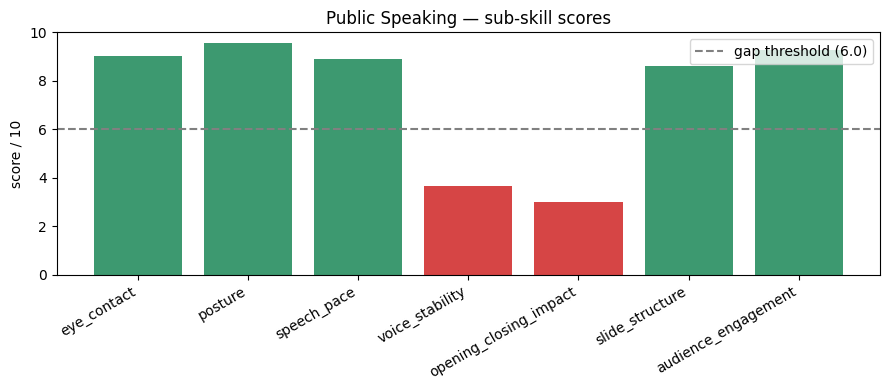

In [20]:
import matplotlib.pyplot as plt

def band_color(score):
    return "#d64545" if score < 4 else ("#e0a82e" if score < 6 else "#3d9970")  # red/amber/green

labels = [s.skill for s in all_scores]
vals = [s.score for s in all_scores]
colors = [band_color(v) for v in vals]

plt.figure(figsize=(9, 4))
plt.bar(labels, vals, color=colors)
plt.axhline(6.0, ls="--", c="grey", label="gap threshold (6.0)")
plt.ylim(0, 10); plt.ylabel("score / 10"); plt.xticks(rotation=30, ha="right")
plt.title("Public Speaking — sub-skill scores"); plt.legend(); plt.tight_layout()
plt.show()

## Step 9 — Adaptive sequencing demo

Rule: a step completed at **>85%** accelerates the next step's difficulty; a skill
scoring **<50% twice** gets a simpler prerequisite inserted. Uses fake completion events.

In [21]:
from services.path_generator import adapt_path

fake_events = [
    {"step_index": 0, "skill": path[0]["skill_addressed"], "score_pct": 92},   # accelerate next
    {"skill": top5[0].skill, "score_pct": 40},                                  # struggle 1
    {"skill": top5[0].skill, "score_pct": 47},                                  # struggle 2 -> prereq
]
adapted = adapt_path(path, fake_events)
print(f"original {len(path)} steps -> adapted {len(adapted)} steps")
for i, step in enumerate(adapted):
    print(f"{i}. [{step['difficulty']}] {step['title']} -> {step['skill_addressed']}")

original 4 steps -> adapted 5 steps
0. [beginner] Prerequisite primer: opening_closing_impact -> opening_closing_impact
1. [beginner] Understanding Opening and Closing Impact in Data Analysis -> opening_closing_impact
2. [advanced] Voice Stability for Effective Communication in Data Analysis -> voice_stability
3. [intermediate] Analyzing and Improving Opening and Closing Impact in Data Analysis -> opening_closing_impact
4. [advanced] Enhancing Voice Stability Through Practice -> voice_stability


## Step 10 — Emit the gap profile to the shared analytics module (Module 5)

In [22]:
from services.analytics_emit import emit_gap_profile_updated
payload = emit_gap_profile_updated(STUDENT_ID, gaps)
print("\nemitted event:", payload["event"], "for", payload["student_id"])

[analytics -> Module 5] {"event": "gap_profile_updated", "student_id": "stu-2026-001", "gaps": [{"skill": "opening_closing_impact", "score": 3.0, "gap_severity": 3.0, "priority_score": 5.1, "dimension": "public_speaking"}, {"skill": "voice_stability", "score": 3.678698344474922, "gap_severity": 2.3213, "priority_score": 3.1338, "dimension": "public_speaking"}]}

emitted event: gap_profile_updated for stu-2026-001


## Step 11 — Multi-video score comparison

Each run appends its 7-score vector (keyed by video) to a JSON file that survives
**Run All**. Swap `STUDENT_VIDEO_URL` in the RUN MODE cell, Run All again, and a new
column appears. Ideal for the #5 *Good vs Bad Presentation* A/B calibration test.


In [ ]:
# ── MULTI-VIDEO SCORE COMPARISON (persists across Run All) ───────────────────
import json, os

COMPARE_FILE = os.path.join(PROJECT_PATH, "score_comparison.json")

def _video_label():
    if LOCAL_DEBUG or not STUDENT_VIDEO_URL:
        return "synthetic"
    url = STUDENT_VIDEO_URL
    base = url.split("v=")[-1][:11] if "v=" in url else url.rstrip("/").split("/")[-1][:11]
    win = ""
    if VIDEO_START is not None or VIDEO_END is not None:
        win = f"@{VIDEO_START or 0}-{VIDEO_END or 'end'}"
    return base + win

label = _video_label()

# Load prior runs, record this one, save.
store = {}
if os.path.exists(COMPARE_FILE):
    with open(COMPARE_FILE) as f:
        store = json.load(f)

store[label] = {s.skill: round(s.score, 2) for s in all_scores}
store[label]["AVERAGE"] = round(sum(s.score for s in all_scores) / len(all_scores), 2)

with open(COMPARE_FILE, "w") as f:
    json.dump(store, f, indent=2)

# ── Side-by-side table: rows = sub-skills, columns = videos ──────────────────
skills = [s.skill for s in all_scores] + ["AVERAGE"]
videos = list(store.keys())
col_w = max(12, max((len(v) for v in videos), default=12) + 2)

header = f"{'sub-skill':<26}" + "".join(f"{v:>{col_w}}" for v in videos)
print(header)
print("\u2500" * len(header))
for sk in skills:
    sep = "\u2500" * len(header) if sk == "AVERAGE" else None
    if sep: print(sep)
    row = f"{sk:<26}"
    for v in videos:
        val = store[v].get(sk)
        row += f"{val:>{col_w}.2f}" if isinstance(val, (int, float)) else f"{'':>{col_w}}"
    print(row)

# ── A/B delta when exactly two videos recorded ───────────────────────────────
if len(videos) == 2:
    a, b = videos
    print(f"\n\u0394 ({b} \u2212 {a}):")
    for sk in skills:
        va, vb = store[a].get(sk), store[b].get(sk)
        if isinstance(va, (int, float)) and isinstance(vb, (int, float)):
            d = vb - va
            arrow = "\u2191" if d > 0 else ("\u2193" if d < 0 else "=")
            print(f"  {sk:<24} {d:+6.2f} {arrow}")

print(f"\n{len(videos)} run(s) in {COMPARE_FILE}")
print("Swap STUDENT_VIDEO_URL + Run All to add a column. Delete the file to reset.")


## Step 12 — Serve the dimension over HTTP (thin FastAPI wrapper)

The same scores can be driven through the live REST API (`api/main.py`). Here we
use FastAPI's in-process `TestClient` so it runs on Colab with no port/server —
the exact same request/response path a real `uvicorn` server would handle.
Demonstrates **AC-09** over HTTP: scores \u2192 gaps \u2192 path \u2192 completion event \u2192 adapted path.

> To run it as a real server instead:
> `pip install -r requirements-api.txt && uvicorn api.main:app --port 8400`
> then open http://localhost:8400 for the **My Learning Path** widget.


In [24]:
# ── HTTP loop demo via in-process TestClient (works on Colab, no server) ─────
try:
    from fastapi.testclient import TestClient
    from api.main import app
    from api import store as _api_store

    _api_store.reset()
    cli = TestClient(app)
    SID = STUDENT_ID  # from Step 5

    # Real scores computed earlier -> JSON payload for POST /scores
    payload = {"scores": [
        {"skill": s.skill, "score": float(s.score), "source": s.source.value}
        for s in all_scores
    ]}

    print("POST /scores/" + SID)
    r = cli.post(f"/scores/{SID}", json=payload)
    gaps = r.json()["gaps"]
    print(f"  -> {len(gaps)} gap(s):", [g["skill"] for g in gaps])

    print("POST /path/generate/" + SID)
    r = cli.post(f"/path/generate/{SID}", json={"target_role": "Data Analyst", "pace": "moderate"})
    steps = r.json()["steps"]
    print(f"  -> {len(steps)} step(s); daily focus: '{steps[0]['title']}'")

    print("POST /path/event/" + SID, "(complete step 0 @ 92%)")
    ev = {"events": [{"step_index": 0, "skill": steps[0]["skill_addressed"], "score_pct": 92}]}
    r = cli.post(f"/path/event/{SID}", json=ev)
    print(f"  -> adapted to {len(r.json()['steps'])} step(s); progress {r.json()['progress_pct']}%")

    print("GET /gaps/" + SID + "/summary")
    print("  ->", cli.get(f"/gaps/{SID}/summary").json())

    print("\n\u2705  HTTP loop OK \u2014 the dimension is live-serviceable (AC-09 over REST).")
except ModuleNotFoundError as e:
    print("\u23ed\ufe0f  Skipping HTTP demo \u2014 install fastapi: pip install fastapi httpx")
    print("    (", e, ")")


POST /scores/stu-2026-001
[analytics -> Module 5] {"event": "gap_profile_updated", "student_id": "stu-2026-001", "gaps": [{"skill": "opening_closing_impact", "score": 3.0, "gap_severity": 3.0, "priority_score": 5.1, "dimension": "public_speaking"}, {"skill": "voice_stability", "score": 3.678698344474922, "gap_severity": 2.3213, "priority_score": 3.1338, "dimension": "public_speaking"}]}
  -> 2 gap(s): ['opening_closing_impact', 'voice_stability']
POST /path/generate/stu-2026-001
  -> 2 step(s); daily focus: 'Eye Contact Fundamentals'
POST /path/event/stu-2026-001 (complete step 0 @ 92%)
  -> adapted to 2 step(s); progress 50.0%
GET /gaps/stu-2026-001/summary
  -> {'student_id': 'stu-2026-001', 'total_gaps': 2, 'critical_gaps': 1, 'top_3_gaps': [{'skill': 'opening_closing_impact', 'score': 3.0, 'gap_severity': 3.0, 'priority_score': 5.1, 'dimension': 'public_speaking'}, {'skill': 'voice_stability', 'score': 3.678698344474922, 'gap_severity': 2.3213, 'priority_score': 3.1338, 'dimension'

## Step 13 — Aggregated profile (the *reliable* score)

One video is a **noisy snapshot**; a student's true skill is the **average across
several videos**. This cell reads every video recorded by Step 11
(`score_comparison.json`) and computes a stable mean ± std per sub-skill, then
re-runs gap detection on the averaged profile.

**Memory-safe:** it reads stored scores — it does NOT re-run YOLO/Whisper/Qwen,
so it adds zero GPU load. To populate it, run the notebook on 2-3 different
`STUDENT_VIDEO_URL`s (Step 3), then run this cell.


In [ ]:
# \u2500\u2500 AGGREGATED PROFILE \u2014 reliable score = mean across readings \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
# Uses the unit-tested services/aggregate_profile.py (was inline math).
import json, os
from services.aggregate_profile import aggregate_scores
from services.gap_detector import detect_gaps
from dimensions.public_speaking.taxonomy_ps import DEMAND_BOOSTS

COMPARE_FILE = os.path.join(PROJECT_PATH, "score_comparison.json")
store = json.load(open(COMPARE_FILE)) if os.path.exists(COMPARE_FILE) else {}
videos = [v for v in store if v != "synthetic"] or list(store)

if len(videos) < 2:
    print(f"\u26a0\ufe0f  Only {len(videos)} video(s) recorded \u2014 aggregation needs \u2265 2.")
    print("    Swap STUDENT_VIDEO_URL (Step 3), Run All again, then re-run this cell.")
    print("    The #5 'Good vs Bad' clip is the ideal A/B calibration pair.")
else:
    runs = [store[v] for v in videos]
    agg = aggregate_scores(runs)
    print(f"Aggregating {agg['n_runs']} readings: {videos}\n")
    print(f"{'sub-skill':<26}{'mean':>7}{'std':>7}{'min':>7}{'max':>7}   reliability")
    print("\u2500" * 70)
    for sk, st in agg["per_skill"].items():
        print(f"{sk:<26}{st['mean']:>7.2f}{st['std']:>7.2f}{st['min']:>7.2f}{st['max']:>7.2f}   {st['flag']}")
    stable_gaps = detect_gaps(agg["scores"], DEMAND_BOOSTS)
    print("\u2500" * 70)
    print(f"Stable-profile gaps ({len(stable_gaps)}):",
          [f"{g.skill}({g.score:.1f})" for g in stable_gaps] or "none")
    if agg["noisiest"]:
        n = agg["noisiest"]
        print(f"\nMost variable sub-skill: '{n}' (std={agg['per_skill'][n]['std']}) \u2014 trust its single read least.")
    print("Takeaway: the averaged profile is the reliable assessment; one video is a draft reading.")

## Step 14 \u2014 A/B accuracy oracle (same-speaker good-vs-bad)

The cheapest ground truth: the *same speaker* must score higher on the good take than the bad take. Workflow for the within-clip pair (`V8eLdbKXGzk`):

1. Step 3: set `STUDENT_VIDEO_URL` to the clip, `VIDEO_START=0`, `VIDEO_END=<bad-segment-end>` \u2192 **Run All**.
2. Step 3: set `VIDEO_START=<good-segment-start>`, `VIDEO_END=None` \u2192 **Run All** again.
3. Run this cell: it picks the two windowed labels and asserts good > bad.

Uses the unit-tested `services/ab_test.py`. Across-video pairs work too \u2014 just set `AB_BAD_LABEL`/`AB_GOOD_LABEL` to any two recorded labels.

In [ ]:
# \u2500\u2500 A/B ORACLE: does the scorer rank the good take above the bad take? \u2500\u2500\u2500
import json, os
from services.ab_test import compare_runs

COMPARE_FILE = os.path.join(PROJECT_PATH, "score_comparison.json")
store = json.load(open(COMPARE_FILE)) if os.path.exists(COMPARE_FILE) else {}

# Set these explicitly, or leave None to auto-pick the two most recent windows.
AB_BAD_LABEL = None
AB_GOOD_LABEL = None
labels = list(store)

if AB_BAD_LABEL is None or AB_GOOD_LABEL is None:
    if len(labels) < 2:
        print(f"\u26a0\ufe0f  Need 2 recorded runs; have {len(labels)}: {labels}")
        print("    Run the bad window, then the good window (Step 3 \u2192 Run All) \u2014 see above.")
        AB_BAD_LABEL = AB_GOOD_LABEL = None
    else:
        AB_BAD_LABEL, AB_GOOD_LABEL = labels[-2], labels[-1]

if AB_BAD_LABEL and AB_GOOD_LABEL:
    res = compare_runs(store[AB_BAD_LABEL], store[AB_GOOD_LABEL])
    print(f"BAD  = {AB_BAD_LABEL}   (mean {res['mean_bad']})")
    print(f"GOOD = {AB_GOOD_LABEL}  (mean {res['mean_good']})\n")
    print(f"{'sub-skill':<26}{'bad':>7}{'good':>7}{'delta':>8}   ")
    print("\u2500" * 56)
    for sk, v in res["per_skill"].items():
        mark = "\u2191" if v["improved"] else "\u2193"
        print(f"{sk:<26}{v['bad']:>7.2f}{v['good']:>7.2f}{v['delta']:>+8.2f}  {mark}")
    print("\u2500" * 56)
    print(f"{res['n_improved']}/{res['n_skills']} sub-skills improved | "
          f"mean delta {res['mean_delta']:+.2f} | VERDICT: {res['verdict']}")
    if res["verdict"] == "PASS":
        print("\u2705 The scorer tracks the quality delta \u2014 metric is trustworthy on this pair.")
    else:
        print("\u274c The good take did NOT clearly beat the bad take \u2014 investigate the scorer.")

## Step 15 \u2014 Live-feed rolling scores (streaming, ByteTrack stable IDs)

The batch cells score a whole file. A **live feed** is scored *as it plays*, in rolling windows, so feedback appears mid-talk. `FrameSource` accepts a webcam index (`0`), a file path, or an `rtsp://` / `http(s)://` stream URL; `stream_pose_records` drives ByteTrack (stable person IDs); `score_stream` emits one per-person + presenter reading per window. Same scorers as the batch path, so live and batch scores of the same footage match.

All windowing/scoring logic is unit-tested in `tests/test_live_feed.py`.

In [ ]:
# \u2500\u2500 STEP 15: live-feed rolling scores \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
from services.live_feed import score_stream

if not LOCAL_DEBUG:
    from ultralytics import YOLO
    from services.live_feed import FrameSource, stream_pose_records
    # The downloaded VIDEO stands in for a stream. For a real camera use
    # FrameSource(0); for a network camera FrameSource("rtsp://...").
    track_model = YOLO("yolov8n-pose.pt")
    with FrameSource(VIDEO) as src:
        records = list(stream_pose_records(src, track_model, every=15))
    print(f"streamed {len(records)} frames (ByteTrack stable IDs)\n")
else:
    # Local: synthesize a short 2-person stream of stable-ID records.
    def _kp(x, y):
        return {"nose": (x, y, 0.9), "left_eye": (x-10, y-5, 0.9), "right_eye": (x+10, y-5, 0.9),
                "left_shoulder": (x-20, y+70, 0.9), "right_shoulder": (x+20, y+70, 0.9)}
    records = [{1: _kp(100, 50), 2: _kp(400, 60)} for _ in range(40)]
    print(f"synthetic stream: {len(records)} frames\n")

for r in score_stream(records, window=20, stride=10):
    p = r["presenter"]
    if p:
        print(f"  window {r['window']}: {len(r['per_person'])} person(s) | "
              f"presenter eye_contact={p['eye_contact']:.1f} posture={p['posture']:.1f} visible={p['visible']}")